# Entraînement et évaluation

Le but du notebook est : 
- Le chargement et la préparation des données
- La recherche d'hyperparamètres
- La définition des modèles
- L'entraînement des modèles
- Leur comparaison d'efficacité
- leur évaluation face à un modèle GDD

## Configuration

In [4]:
#Configuration
srcFile = "../data/processed/consolidated/consolidated.parquet"
evaluationStatsFile = "../models/stats-modeles.csv"
modelsFolder = "../models/"

In [5]:
#Chargement des librairies
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import pickle
import numpy as np
import gc

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV



## Chargement et préparation des données

In [6]:
#Chargement des données consolidées
df = pd.read_parquet(srcFile, engine="fastparquet")

In [7]:
#Séparation X et y et échantillonnage
# le code garantit qu'aucun site×année ne se retrouve à la fois dans le train et dans 
# la validation (anti-fuite), et que la validation conserve des trajectoires complètes 
# plutôt que des lignes éparses, ce qui est indispensable pour évaluer les snapshots 
# à jour fixe.

N_TRAIN         = 500_000   # lignes d'entraînement
N_VALID_GROUPES = 100       # groupes complets en validation (~700k lignes)

#On sépare les X et y (on supprime de X le label ainsi que date qui n'est pas utile dans notre cas)
y = df["n_avant_floraison"]
X = df.drop(["n_avant_floraison", "date"], axis=1)

#Séries de chaines de caractères qui sont des identifiant unique par site/année (càd trajectoire)
groupes = (
    X['latitude'].astype(str) + '_' +
    X['longitude'].astype(str) + '_' +
    X['annee'].astype(str)
)
print(f"Nombre de groupes site×année : {groupes.nunique()}")

#Sépare les données par groupe entier et pas par ligne individuel. 20% des groupes dans la validation
#Pur éviter la fuite de données, càd des trajectoires qui se retrouvent à la fois en train et validation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(gss.split(X, y, groupes))

np.random.seed(42)

# Échantillonnage du train : lignes aléatoires, pas besoin des trajectoires complètes
train_sample = np.random.choice(train_idx, size=min(N_TRAIN, len(train_idx)), replace=False)

# Échantillonnage du valid : groupes entiers tirés aléatoirement (entiers pour le calcul des snapshots à 15, 30, 60 etc.)
groupes_valid_uniques = groupes.iloc[valid_idx].unique() #Liste les groupes présents en valid
groupes_valid_sample  = np.random.choice(groupes_valid_uniques, size=min(N_VALID_GROUPES, len(groupes_valid_uniques)), replace=False) #100 groupes au hasard
mask_valid            = groupes.iloc[valid_idx].isin(groupes_valid_sample).values
valid_sample          = valid_idx[mask_valid] #Ne garder que les indices des lignes appartenant aux 100 groupes retenus

#Df finaux
X_train = X.iloc[train_sample].reset_index(drop=True)
y_train = y.iloc[train_sample].reset_index(drop=True)
X_valid = X.iloc[valid_sample].reset_index(drop=True)
y_valid = y.iloc[valid_sample].reset_index(drop=True)

print(f"Lignes entraînement : {X_train.shape[0]:,}")
print(f"Lignes validation   : {X_valid.shape[0]:,} ({len(groupes_valid_sample)} groupes complets)")


Nombre de groupes site×année : 2561
Lignes entraînement : 500,000
Lignes validation   : 610,026 (100 groupes complets)


## Recherche d'hyperparamètres

### Gradient Boosting

In [33]:

param_dist = {
    'loss': ['squared_error', 'absolute_error', 'huber'],
    'learning_rate': uniform(0.01, 0.19),
    'n_estimators': randint(50, 201),
    'max_depth': [3, 4, 5]
}

search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,          # 30 combinaisons au lieu de 360 fits
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=2,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print("Meilleurs paramètres:", search.best_params_)
print("Meilleur score:", search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres: {'learning_rate': np.float64(0.15814129005182617), 'loss': 'squared_error', 'max_depth': 5, 'n_estimators': 171}
Meilleur score: -28.885177469226676


### KNN

In [ ]:
#Pour le KNN : estimation du meilleur K
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Méthode 1 : Validation croisée manuelle
k_values = range(1, 31)  # Tester k de 1 à 30
cv_scores = []
cv_std = []

for k in k_values:
    pipeline = Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', KNeighborsRegressor(n_neighbors=k))
        ]
    )

    # Validation croisée (par défaut 5 folds)
    scores = cross_val_score(pipeline, X_train, y_train, 
                            cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # Convertir en MSE positif
    cv_std.append(scores.std())


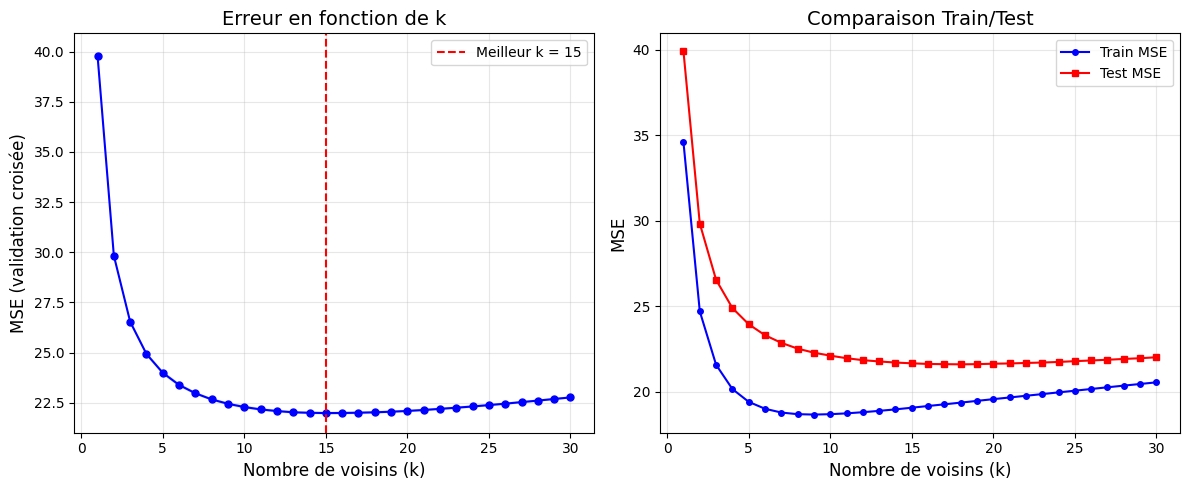

Meilleur k : 15
MSE minimal : 21.9890


In [ ]:
# Visualisation

plt.figure(figsize=(12, 5))

# Graphique 1 : MSE en fonction de k
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, 'b-', marker='o', markersize=5)
plt.fill_between(k_values, 
                 np.array(cv_scores) - np.array(cv_std),
                 np.array(cv_scores) + np.array(cv_std),
                 alpha=0.2)
plt.xlabel('Nombre de voisins (k)', fontsize=12)
plt.ylabel('MSE (validation croisée)', fontsize=12)
plt.title('Erreur en fonction de k', fontsize=14)
plt.grid(True, alpha=0.3)

# Identifier le meilleur k
best_k = k_values[np.argmin(cv_scores)]
plt.axvline(x=best_k, color='r', linestyle='--', 
            label=f'Meilleur k = {best_k}')
plt.legend()

# Graphique 2 : Comparaison train/test (optionnel)
plt.subplot(1, 2, 2)
train_scores = []
test_scores = []

for k in k_values:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    pipeline.fit(X_train, y_train)
    
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_valid)
    
    train_scores.append(mean_squared_error(y_train, train_pred))
    test_scores.append(mean_squared_error(y_valid, test_pred))

plt.plot(k_values, train_scores, 'b-', marker='o', 
         markersize=4, label='Train MSE')
plt.plot(k_values, test_scores, 'r-', marker='s', 
         markersize=4, label='Test MSE')
plt.xlabel('Nombre de voisins (k)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Comparaison Train/Test', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Meilleur k : {best_k}")
print(f"MSE minimal : {min(cv_scores):.4f}")

### Forêt aléatoire

In [34]:
rfr = RandomForestRegressor(
    random_state=42,
    n_jobs=1          # le SearchCV gère le parallélisme
)

param_dist = {
    'n_estimators': randint(50, 201),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'max_samples': uniform(0.5, 0.5)   # subsample des données par arbre (0.5 à 1.0)
}

search = HalvingRandomSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    factor=3,          # élimine 2/3 des candidats à chaque ronde
    resource='n_samples',
    min_resources='smallest',
    n_jobs=2,          # parallélisme contrôlé
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Meilleurs paramètres:", search.best_params_)
print("Meilleur score:", search.best_score_)

n_iterations: 10
n_required_iterations: 10
n_possible_iterations: 10
min_resources_: 10
max_resources_: 500000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50000
n_resources: 10
Fitting 5 folds for each of 50000 candidates, totalling 250000 fits
----------
iter: 1
n_candidates: 16667
n_resources: 30
Fitting 5 folds for each of 16667 candidates, totalling 83335 fits
----------
iter: 2
n_candidates: 5556
n_resources: 90
Fitting 5 folds for each of 5556 candidates, totalling 27780 fits
----------
iter: 3
n_candidates: 1852
n_resources: 270
Fitting 5 folds for each of 1852 candidates, totalling 9260 fits
----------
iter: 4
n_candidates: 618
n_resources: 810
Fitting 5 folds for each of 618 candidates, totalling 3090 fits
----------
iter: 5
n_candidates: 206
n_resources: 2430
Fitting 5 folds for each of 206 candidates, totalling 1030 fits
----------
iter: 6
n_candidates: 69
n_resources: 7290
Fitting 5 folds for each of 69 candidates, totalling 345 fits
----------


/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 9
n_candidates: 3
n_resources: 196830
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Meilleurs paramètres: {'max_depth': 20, 'max_features': 0.5, 'max_samples': np.float64(0.9709321177823373), 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 134}
Meilleur score: -33.784059287348086


## Entraînement et évaluation des modèles

In [9]:
#Fonctions pour validations croisées

def vc_lasso(X_train, X_valid, y_train, y_valid):
    lasso_cv = LassoCV(alphas=None, cv=5, max_iter=1000)
    lasso_cv.fit(X_train, y_train)
    print(f"Meilleur alpha: {lasso_cv.alpha_}")
    return lasso_cv.alpha_

def vc_ridge(X_train, X_valid, y_train, y_valid):
    ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
    ridge_cv.fit(X_train, y_train)
    print(f"Meilleur alpha: {ridge_cv.alpha_}")
    return ridge_cv.alpha_

In [10]:
#Configuration des modèles
modeles = {
    'Régression Lineaire' : {
        'model' : LinearRegression,
        'normalisation' : True,
        'vc' : None,
        'arguments' : {},
        'filename' : 'regressionlineaire.pkl'
    },
    'Régression pénalisée Ridge L2' : {
        'model' : Ridge,
        'normalisation' : True,
        'vc' : vc_ridge,
        'vcArg' : 'alpha',
        'arguments' : {'alpha' : 1.0},
        'filename' : 'regressionpenalisee_l2.pkl'
    },
    'Régression pénalisée Lasso L1' : {
        'model' : Lasso,
        'normalisation' : True,
        'vc' :  vc_lasso,
        'vcArg' : 'alpha',
        'arguments' : {'alpha' : 1.0, 'max_iter' : 1000},
        'filename' : 'regressionpenalisee_l1.pkl'
    },
    'Régression pénalisée ElasticNet' : {
        'model' : ElasticNet,
        'normalisation' : True,
        'vc' : None,
        'arguments' : {'alpha' : 1.0, 'l1_ratio' : 0.5, 'max_iter' : 1000},
        'filename' : 'regressionpenalisee_elastic.pkl'
    },
    'KNN' : {
        'model' : KNeighborsRegressor,
        'normalisation' : True,
        'vc' : None,
        'arguments' : {'n_neighbors' : 15},
        'filename' : 'KNN.pkl'
    },
    'Arbre de décision' : {
        'model' : tree.DecisionTreeRegressor,
        'normalisation' : False,
        'vc' : None,
        'arguments' : {'criterion' : 'squared_error'},
        'filename' : 'decisiontree.pkl'
    },
    'Forêt aléatoire' : {
        'model' : RandomForestRegressor,
        'normalisation' : False,
        'vc' : None,
        'arguments' : {'n_estimators' : 134, 'random_state' : 0, 'max_depth': 20, 'max_features': 0.5, 'max_samples': np.float64(0.9709321177823373), 'min_samples_leaf': 1, 'min_samples_split': 4},
        'filename' : 'randomforest.pkl'
    },
    'Gradient boosting' : {
        'model' : GradientBoostingRegressor,
        'normalisation' : False,
        'vc' : None,
        'arguments' : {'learning_rate': 0.2, 'loss': 'squared_error', 'max_depth': 7, 'n_estimators': 200},
        'filename' : 'gradientboosting.pkl'
    },
}

In [7]:
#Fonction d'entrainement
from time import time
import pickle
import os


#Données de tracking
tracking = {
    'model' : [],
    'trainingTime' : [],

    #MAE : nombre de jours moyens d'erreur
    'mae_train' : [],
    'mae_valid' : [],

    #RMSE : idem mais avec pénalisation des erreurs "graves"
    'rmse_train' : [],
    'rmse_valid' : [],

    #% de prédictions justes à +/- 3 jours et 7 jours
    'pct3j_valid' : [],
    'pct7j_valid' : [],

    #MAE et RMSE effectuées à jour 15, 30, 45, 60 et 90
    'mae_j15_valid' : [],
    'rmse_j15_valid' : [],
    'mae_j30_valid' : [],
    'rmse_j30_valid' : [],
    'mae_j45_valid' : [],
    'rmse_j45_valid' : [],
    'mae_j60_valid' : [],
    'rmse_j60_valid' : [],
    'mae_j90_valid' : [],
    'rmse_j90_valid' : [],

    #R2 : métrique inutile dans notre cas
    'r2_train' : [],
    'r2_valid' : [],

    #Taille du modèle
    'poids' : []
}


def train_modele(modeleName, modelConfig, X_train, X_valid, y_train, y_valid, tracking):
    print("=============================================================")
    print(f"Entrainement du modèle {modeleName}")

    tracking["model"].append(modeleName)

    #Validation croisée
    if modelConfig["vc"]:
        print("Validation croisée !")
        a = modelConfig["vc"](X_train, X_valid, y_train, y_valid)
        modelConfig["arguments"][modelConfig["vcArg"]] = a

    print(modelConfig["arguments"])

    #Creation du pipeline -> on intègre la normalisation des données
    steps = []
    if modelConfig["normalisation"]:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', modelConfig["model"](**modelConfig["arguments"])))
    pipeline = Pipeline(steps=steps)

    #Entraîne le modèle
    ms_start = int(time() * 1000)
    pipeline.fit(X_train, y_train)
    ms_end = int(time() * 1000)
    print(f"Entraînement terminé en {ms_end-ms_start} ms")
    tracking["trainingTime"].append(ms_end-ms_start)

    #Prédictions globales
    y_pred_valid = pipeline.predict(X_valid)
    y_pred_train = pipeline.predict(X_train)

    # MAE
    score_mae_valid = mean_absolute_error(y_valid, y_pred_valid)
    score_mae_train = mean_absolute_error(y_train, y_pred_train)
    print('MAE (jeu de validation) :', score_mae_valid)
    print("MAE (jeu d\'entraînement) :", score_mae_train)

    # RMSE
    score_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    score_rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
    print('RMSE (jeu de validation) :', score_rmse_valid)
    print("RMSE (jeu d\'entraînement) :", score_rmse_train)


    # % de prédictions dans une fenêtre de ±3j et ±7j
    pct3j_valid = np.mean(np.abs(np.array(y_valid) - y_pred_valid) <= 3) * 100
    pct7j_valid = np.mean(np.abs(np.array(y_valid) - y_pred_valid) <= 7) * 100
    print(f'% à ±3 jours (valid) : {pct3j_valid:.1f}%')
    print(f'% à ±7 jours (valid) : {pct7j_valid:.1f}%')

    # Métriques snapshot : MAE + RMSE au jour J
    print("--- Métriques snapshot (usage réel) ---")
    mask_j15 = X_valid['jour_n'] == 15
    if mask_j15.sum() > 0:
        mae_j15  = mean_absolute_error(y_valid[mask_j15], pipeline.predict(X_valid[mask_j15]))
        rmse_j15 = np.sqrt(mean_squared_error(y_valid[mask_j15], pipeline.predict(X_valid[mask_j15])))
    else:
        mae_j15 = rmse_j15 = np.nan
    print(f'Snapshot jour  15 — MAE : {mae_j15:.2f} j  RMSE : {rmse_j15:.2f} j  ({mask_j15.sum()} obs)')
    mask_j30 = X_valid['jour_n'] == 30
    if mask_j30.sum() > 0:
        mae_j30  = mean_absolute_error(y_valid[mask_j30], pipeline.predict(X_valid[mask_j30]))
        rmse_j30 = np.sqrt(mean_squared_error(y_valid[mask_j30], pipeline.predict(X_valid[mask_j30])))
    else:
        mae_j30 = rmse_j30 = np.nan
    print(f'Snapshot jour  30 — MAE : {mae_j30:.2f} j  RMSE : {rmse_j30:.2f} j  ({mask_j30.sum()} obs)')
    mask_j45 = X_valid['jour_n'] == 45
    if mask_j45.sum() > 0:
        mae_j45  = mean_absolute_error(y_valid[mask_j45], pipeline.predict(X_valid[mask_j45]))
        rmse_j45 = np.sqrt(mean_squared_error(y_valid[mask_j45], pipeline.predict(X_valid[mask_j45])))
    else:
        mae_j45 = rmse_j45 = np.nan
    print(f'Snapshot jour  45 — MAE : {mae_j45:.2f} j  RMSE : {rmse_j45:.2f} j  ({mask_j45.sum()} obs)')
    mask_j60 = X_valid['jour_n'] == 60
    if mask_j60.sum() > 0:
        mae_j60  = mean_absolute_error(y_valid[mask_j60], pipeline.predict(X_valid[mask_j60]))
        rmse_j60 = np.sqrt(mean_squared_error(y_valid[mask_j60], pipeline.predict(X_valid[mask_j60])))
    else:
        mae_j60 = rmse_j60 = np.nan
    print(f'Snapshot jour  60 — MAE : {mae_j60:.2f} j  RMSE : {rmse_j60:.2f} j  ({mask_j60.sum()} obs)')
    mask_j90 = X_valid['jour_n'] == 90
    if mask_j90.sum() > 0:
        mae_j90  = mean_absolute_error(y_valid[mask_j90], pipeline.predict(X_valid[mask_j90]))
        rmse_j90 = np.sqrt(mean_squared_error(y_valid[mask_j90], pipeline.predict(X_valid[mask_j90])))
    else:
        mae_j90 = rmse_j90 = np.nan
    print(f'Snapshot jour  90 — MAE : {mae_j90:.2f} j  RMSE : {rmse_j90:.2f} j  ({mask_j90.sum()} obs)')

    # Coefficient de détermination (R²)
    r2_train = r2_score(y_train, y_pred_train)
    r2_valid = r2_score(y_valid, y_pred_valid)
    print('R2 (jeu de validation) :', r2_valid)
    print("R2 (jeu d\'entraînement) :", r2_train)

    tracking["mae_train"].append(score_mae_train)
    tracking["mae_valid"].append(score_mae_valid)
    tracking["rmse_train"].append(score_rmse_train)
    tracking["rmse_valid"].append(score_rmse_valid)
    tracking["pct3j_valid"].append(pct3j_valid)
    tracking["pct7j_valid"].append(pct7j_valid)
    tracking['mae_j15_valid'].append(mae_j15)
    tracking['rmse_j15_valid'].append(rmse_j15)
    tracking['mae_j30_valid'].append(mae_j30)
    tracking['rmse_j30_valid'].append(rmse_j30)
    tracking['mae_j45_valid'].append(mae_j45)
    tracking['rmse_j45_valid'].append(rmse_j45)
    tracking['mae_j60_valid'].append(mae_j60)
    tracking['rmse_j60_valid'].append(rmse_j60)
    tracking['mae_j90_valid'].append(mae_j90)
    tracking['rmse_j90_valid'].append(rmse_j90)

    tracking["r2_train"].append(r2_train)
    tracking["r2_valid"].append(r2_valid)

    pickle.dump(pipeline, open(f"{modelsFolder}{modelConfig['filename']}", 'wb'))
    taille_model = os.path.getsize(f"{modelsFolder}{modelConfig['filename']}") / 1024
    print(f"Taille du modèle {taille_model} ko")
    tracking["poids"].append(taille_model)

    print("Quelques exemples de prédictions : ")
    for index in range(0, 5):
        print(f"Valeur réelle : {y_valid.iloc[index]} - valeur prédite : {y_pred_valid[index]:.1f}")

    return tracking


In [8]:
#Entrainement et évaluation
for modele in modeles:
    tracking = train_modele(modele, modeles[modele], X_train, X_valid, y_train, y_valid, tracking)

Entrainement du modèle Régression Lineaire
{}
Entraînement terminé en 407 ms
MAE (jeu de validation) : 7.983545531053595
MAE (jeu d'entraînement) : 7.3536678426510305
RMSE (jeu de validation) : 10.141592464738885
RMSE (jeu d'entraînement) : 9.348110872353027
% à ±3 jours (valid) : 27.1%
% à ±7 jours (valid) : 53.1%
--- Métriques snapshot (usage réel) ---
Snapshot jour  15 — MAE : 8.26 j  RMSE : 10.54 j  (1670 obs)
Snapshot jour  30 — MAE : 8.19 j  RMSE : 10.45 j  (1670 obs)
Snapshot jour  45 — MAE : 8.13 j  RMSE : 10.37 j  (1670 obs)
Snapshot jour  60 — MAE : 8.13 j  RMSE : 10.33 j  (1670 obs)
Snapshot jour  90 — MAE : 8.13 j  RMSE : 10.26 j  (1670 obs)
R2 (jeu de validation) : 0.9908557663569927
R2 (jeu d'entraînement) : 0.9922152094116933
Taille du modèle 1.2470703125 ko
Quelques exemples de prédictions : 
Valeur réelle : 151 - valeur prédite : 154.4
Valeur réelle : 150 - valeur prédite : 153.4
Valeur réelle : 149 - valeur prédite : 152.4
Valeur réelle : 148 - valeur prédite : 151.4


/home/lgerard/python/abeilles/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Meilleur alpha: 74.6615017087294
{'alpha': np.float64(74.6615017087294), 'max_iter': 1000}
Entraînement terminé en 102 ms
MAE (jeu de validation) : 65.18494825322301
MAE (jeu d'entraînement) : 65.0747804243442
RMSE (jeu de validation) : 75.55691528582979
RMSE (jeu d'entraînement) : 75.41822888353951
% à ±3 jours (valid) : 2.3%
% à ±7 jours (valid) : 5.4%
--- Métriques snapshot (usage réel) ---
Snapshot jour  15 — MAE : 120.74 j  RMSE : 121.27 j  (1670 obs)
Snapshot jour  30 — MAE : 110.12 j  RMSE : 110.70 j  (1670 obs)
Snapshot jour  45 — MAE : 99.49 j  RMSE : 100.14 j  (1670 obs)
Snapshot jour  60 — MAE : 88.87 j  RMSE : 89.59 j  (1670 obs)
Snapshot jour  90 — MAE : 67.62 j  RMSE : 68.57 j  (1670 obs)
R2 (jeu de validation) : 0.49244461162979236
R2 (jeu d'entraînement) : 0.49329885733329715
Taille du modèle 1.2998046875 ko
Quelques exemples de prédictions : 
Valeur réelle : 151 - valeur prédite : 12.9
Valeur réelle : 150 - valeur prédite : 12.6
Valeur réelle : 149 - valeur prédite : 1

In [9]:
# Conversion en dataframe
tracking_df = pd.DataFrame(tracking, columns=[
    "model", "trainingTime",
    "mae_train", "mae_valid",
    "rmse_train", "rmse_valid",
    "pct3j_valid", "pct7j_valid",
    "mae_j15_valid",
    "rmse_j15_valid",
    "mae_j30_valid",
    "rmse_j30_valid",
    "mae_j45_valid",
    "rmse_j45_valid",
    "mae_j60_valid",
    "rmse_j60_valid",
    "mae_j90_valid",
    "rmse_j90_valid",
    "r2_train", "r2_valid",
    "poids"
])
tracking_df

,model,trainingTime,mae_train,mae_valid,rmse_train,rmse_valid,pct3j_valid,pct7j_valid,mae_j15_valid,rmse_j15_valid,...,rmse_j30_valid,mae_j45_valid,rmse_j45_valid,mae_j60_valid,rmse_j60_valid,mae_j90_valid,rmse_j90_valid,r2_train,r2_valid,poids
0,Régression Lineaire,407,7.353668,7.983546,9.348111,10.141592,27.061797,53.076426,8.259992,10.538499,...,10.446114,8.133459,10.365456,8.125930,10.329568,8.126947,10.263959,0.992215,0.990856,1.247070e+00
1,Régression pénalisée Ridge L2,72,7.353815,7.982915,9.348114,10.140907,27.052617,53.076098,8.261807,10.540463,...,10.447374,8.133698,10.366014,8.125620,10.329709,8.126700,10.263842,0.992215,0.990857,1.222656e+00
2,Régression pénalisée Lasso L1,102,65.074780,65.184948,75.418229,75.556915,2.313672,5.402393,120.741567,121.272717,...,110.699941,99.494044,100.137958,88.870282,89.590585,67.622759,68.566635,0.493299,0.492445,1.299805e+00
3,Régression pénalisée ElasticNet,124,20.972642,21.585355,26.572929,27.193822,10.695938,22.584939,49.038897,50.141206,...,45.064825,37.844264,39.425592,31.395264,33.384898,18.374035,21.157367,0.937096,0.934253,1.294922e+00
4,KNN,1265,3.836004,6.776546,5.090163,9.020979,31.340959,63.495982,6.382355,8.306048,...,9.046191,7.298443,9.686576,7.022914,9.143359,6.935409,9.095447,0.997692,0.992765,3.976593e+04
5,Arbre de décision,4650,1.600249,6.620567,3.187009,9.027631,36.317468,66.159147,6.845309,9.076853,...,8.086373,6.579099,9.060498,7.094212,9.793581,6.105389,8.448975,0.999095,0.992754,3.628785e+04
6,Forêt aléatoire,180222,2.823091,5.255502,3.934038,6.783457,37.733802,71.916279,5.222743,6.841754,...,6.783020,5.249346,6.858730,5.355756,6.982605,5.203664,6.667156,0.998621,0.995909,1.580991e+06
7,Gradient boosting,428355,3.388996,4.882106,4.604754,6.457499,42.757850,74.375191,4.987734,6.692078,...,6.744717,5.028043,6.748003,4.945908,6.593055,4.852918,6.276389,0.998111,0.996293,3.501831e+03


In [11]:
#Calcul temps inférence (sur 100 lignes)
import time

N_ROWS = 100

X_sample = X_valid.iloc[:N_ROWS]

inference_times = {}

for modele in modeles:
    filename = modeles[modele]['filename']

    with open(f"../models/{filename}", 'rb') as f:
        pipeline = pickle.load(f)

    start = int(time.time() * 1000)
    pipeline.predict(X_sample)
    end = int(time.time() * 1000)
    tm = end - start

    inference_times[modele] = tm
    print(f"{modele:40s} : {tm} ms ({N_ROWS} lignes)")

    del pipeline
    gc.collect()

tracking_df['inferenceTime'] = tracking_df['model'].map(inference_times)

Régression Lineaire                      : 15 ms (100 lignes)
Régression pénalisée Ridge L2            : 1 ms (100 lignes)
Régression pénalisée Lasso L1            : 1 ms (100 lignes)
Régression pénalisée ElasticNet          : 1 ms (100 lignes)
KNN                                      : 3 ms (100 lignes)
Arbre de décision                        : 1 ms (100 lignes)
Forêt aléatoire                          : 5 ms (100 lignes)
Gradient boosting                        : 1 ms (100 lignes)


In [12]:
#Sauvegarde fichier modifié
tracking_df.to_csv(evaluationStatsFile, index=False)
evaluationStatsFile

'../models-v3/stats-modeles.csv'

In [11]:
#Recharge (si nécessaire)
tracking_df = pd.read_csv(evaluationStatsFile)
tracking_df

,model,trainingTime,mae_train,mae_valid,rmse_train,rmse_valid,pct3j_valid,pct7j_valid,mae_j15_valid,rmse_j15_valid,...,mae_j45_valid,rmse_j45_valid,mae_j60_valid,rmse_j60_valid,mae_j90_valid,rmse_j90_valid,r2_train,r2_valid,poids,inferenceTime
0,Régression Lineaire,407,7.353668,7.983546,9.348111,10.141592,27.061797,53.076426,8.259992,10.538499,...,8.133459,10.365456,8.125930,10.329568,8.126947,10.263959,0.992215,0.990856,1.247070e+00,15
1,Régression pénalisée Ridge L2,72,7.353815,7.982915,9.348114,10.140907,27.052617,53.076098,8.261807,10.540463,...,8.133698,10.366014,8.125620,10.329709,8.126700,10.263842,0.992215,0.990857,1.222656e+00,1
2,Régression pénalisée Lasso L1,102,65.074780,65.184948,75.418229,75.556915,2.313672,5.402393,120.741567,121.272717,...,99.494044,100.137958,88.870282,89.590585,67.622759,68.566635,0.493299,0.492445,1.299805e+00,1
3,Régression pénalisée ElasticNet,124,20.972642,21.585355,26.572929,27.193822,10.695938,22.584939,49.038897,50.141206,...,37.844264,39.425592,31.395264,33.384898,18.374035,21.157367,0.937096,0.934253,1.294922e+00,1
4,KNN,1265,3.836004,6.776546,5.090163,9.020979,31.340959,63.495982,6.382355,8.306048,...,7.298443,9.686576,7.022914,9.143359,6.935409,9.095447,0.997692,0.992765,3.976593e+04,3
5,Arbre de décision,4650,1.600249,6.620567,3.187009,9.027631,36.317468,66.159147,6.845309,9.076853,...,6.579099,9.060498,7.094212,9.793581,6.105389,8.448975,0.999095,0.992754,3.628785e+04,1
6,Forêt aléatoire,180222,2.823091,5.255502,3.934038,6.783457,37.733802,71.916279,5.222743,6.841754,...,5.249346,6.858730,5.355756,6.982605,5.203664,6.667156,0.998621,0.995909,1.580991e+06,5
7,Gradient boosting,428355,3.388996,4.882106,4.604754,6.457499,42.757850,74.375191,4.987734,6.692078,...,5.028043,6.748003,4.945908,6.593055,4.852918,6.276389,0.998111,0.996293,3.501831e+03,1


## Visualisation des métriques

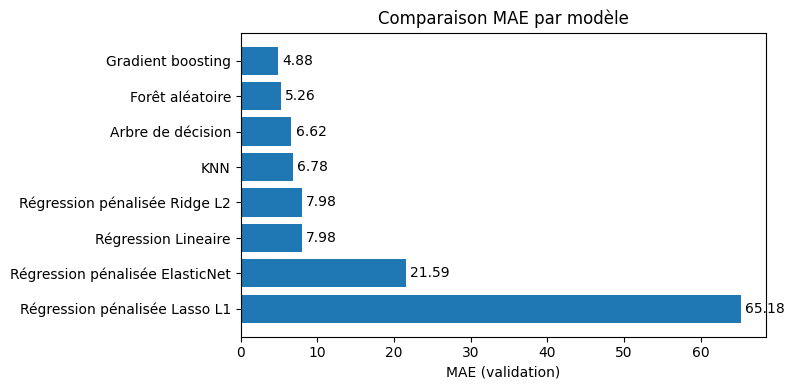

In [9]:
# Comparaison MAE
sorted_df = tracking_df.sort_values('mae_valid', ascending=False)
noms_modeles = sorted_df['model']
mae_values = sorted_df['mae_valid']

plt.figure(figsize=(8, 4))
bars = plt.barh(noms_modeles, mae_values)
plt.bar_label(bars, fmt='%.2f', padding=3)
plt.xlabel('MAE (validation)')
plt.title('Comparaison MAE par modèle')
plt.tight_layout()

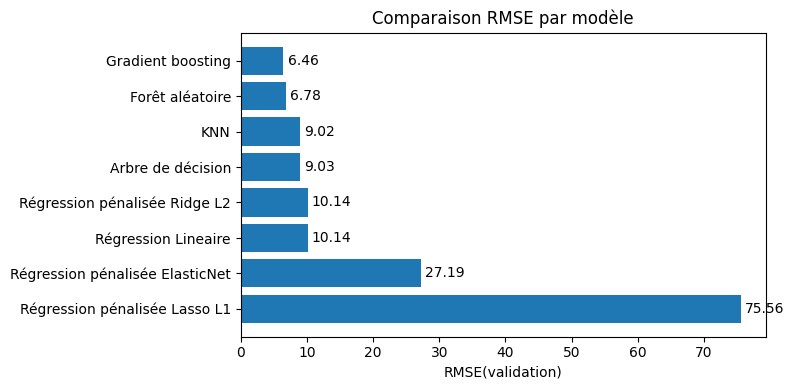

In [10]:
# Comparaison RMSE
sorted_df = tracking_df.sort_values('rmse_valid', ascending=False)
noms_modeles = sorted_df['model']
mae_values = sorted_df['rmse_valid']

plt.figure(figsize=(8, 4))
bars = plt.barh(noms_modeles, mae_values)
plt.bar_label(bars, fmt='%.2f', padding=3)
plt.xlabel('RMSE(validation)')
plt.title('Comparaison RMSE par modèle')
plt.tight_layout()

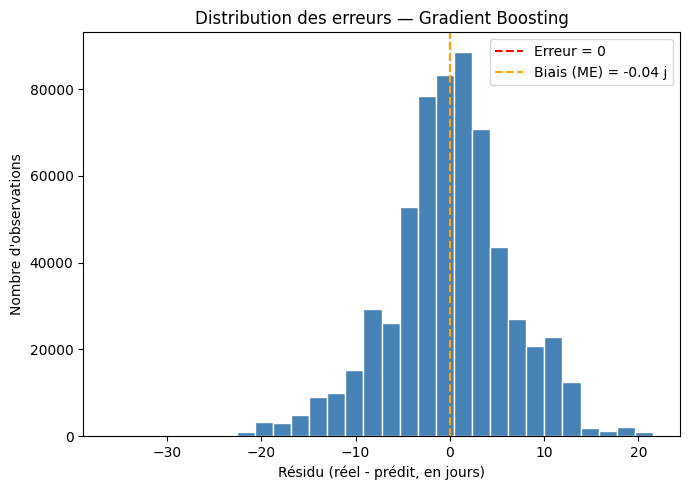

Biais (ME)  : -0.04 j
MAE         : 4.88 j
RMSE        : 6.46 j
% erreur <=3j: 42.8%
% erreur <=7j: 74.4%


In [11]:
# Distribution des erreurs — Gradient Boosting
import pickle

with open('../models/gradientboosting.pkl', 'rb') as f:
    pipeline_gb = pickle.load(f)

y_pred_gb = pipeline_gb.predict(X_valid)
residus = y_valid - y_pred_gb

fig, ax = plt.subplots(figsize=(7, 5))

# Histogramme des résidus
ax.hist(residus, bins=30, edgecolor='white', color='steelblue')
ax.axvline(0, color='red', linestyle='--', label='Erreur = 0')
ax.axvline(residus.mean(), color='orange', linestyle='--', label=f'Biais (ME) = {residus.mean():.2f} j')
ax.set_xlabel('Résidu (réel - prédit, en jours)')
ax.set_ylabel("Nombre d'observations")
ax.set_title('Distribution des erreurs — Gradient Boosting')
ax.legend()


plt.tight_layout()
plt.show()

print(f"Biais (ME)  : {residus.mean():.2f} j")
print(f"MAE         : {residus.abs().mean():.2f} j")
print(f"RMSE        : {(residus**2).mean()**0.5:.2f} j")
print(f"% erreur <=3j: {(residus.abs() <= 3).mean()*100:.1f}%")
print(f"% erreur <=7j: {(residus.abs() <= 7).mean()*100:.1f}%")


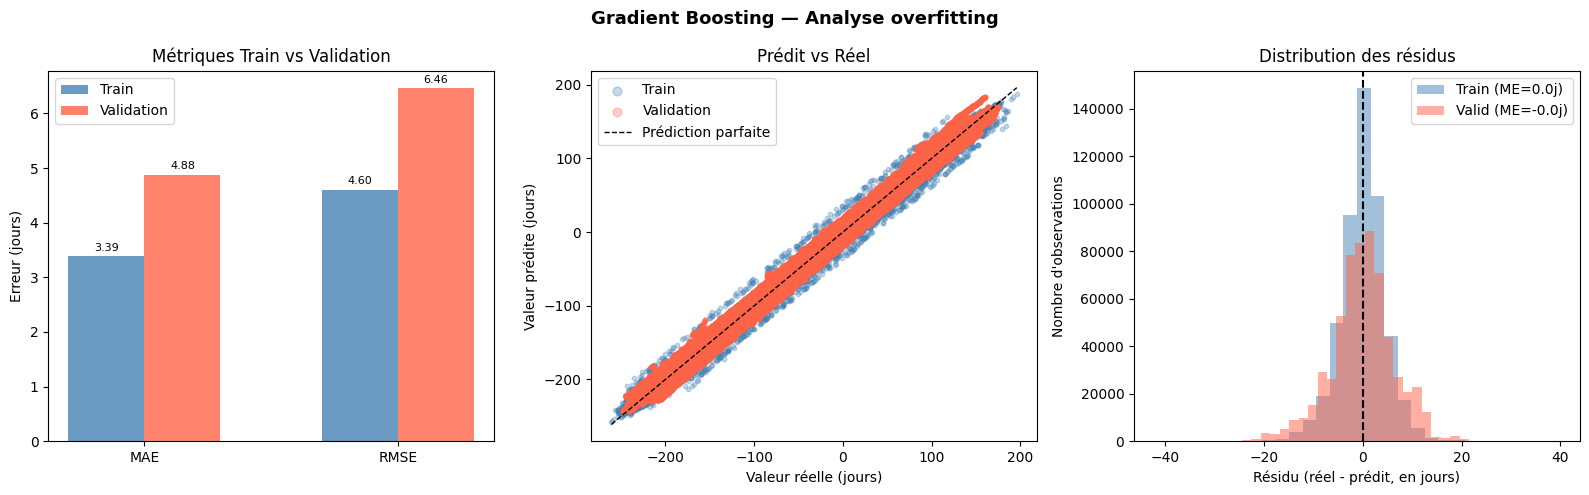

In [17]:
# Overfitting — Gradient Boosting : train vs validation
# pipeline_gb chargé dans la cellule précédente

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred_train_gb = pipeline_gb.predict(X_train)
y_pred_valid_gb = pipeline_gb.predict(X_valid)

mae_train = mean_absolute_error(y_train, y_pred_train_gb)
mae_valid = mean_absolute_error(y_valid, y_pred_valid_gb)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_gb))
rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid_gb))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Graphique 1 : Métriques train vs valid ---
x = [0, 1]
width = 0.3
axes[0].bar([0 - width/2, 1 - width/2], [mae_train, rmse_train], width=width, label="Train", color="steelblue", alpha=0.8)
axes[0].bar([0 + width/2, 1 + width/2], [mae_valid, rmse_valid], width=width, label="Validation", color="tomato", alpha=0.8)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["MAE", "RMSE"])
axes[0].set_title("Métriques Train vs Validation")
axes[0].set_ylabel("Erreur (jours)")
axes[0].legend()
for v, x_pos in zip([mae_train, rmse_train], [0 - width/2, 1 - width/2]):
    axes[0].text(x_pos, v + 0.1, f"{v:.2f}", ha="center", fontsize=8)
for v, x_pos in zip([mae_valid, rmse_valid], [0 + width/2, 1 + width/2]):
    axes[0].text(x_pos, v + 0.1, f"{v:.2f}", ha="center", fontsize=8)

# --- Graphique 2 : Prédit vs Réel ---
axes[1].scatter(y_train, y_pred_train_gb, alpha=0.3, s=10, color="steelblue", label="Train")
axes[1].scatter(y_valid, y_pred_valid_gb, alpha=0.3, s=10, color="tomato", label="Validation")
lims = [min(y_train.min(), y_valid.min()), max(y_train.max(), y_valid.max())]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Prédiction parfaite")
axes[1].set_xlabel("Valeur réelle (jours)")
axes[1].set_ylabel("Valeur prédite (jours)")
axes[1].set_title("Prédit vs Réel")
axes[1].legend(markerscale=2)

# --- Graphique 3 : Distribution des résidus train vs valid ---
residus_train = y_train - y_pred_train_gb
residus_valid = y_valid - y_pred_valid_gb
axes[2].hist(residus_train, bins=30, alpha=0.5, color="steelblue", label=f"Train (ME={residus_train.mean():.1f}j)")
axes[2].hist(residus_valid, bins=30, alpha=0.5, color="tomato", label=f"Valid (ME={residus_valid.mean():.1f}j)")
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_xlabel("Résidu (réel - prédit, en jours)")
axes[2].set_ylabel("Nombre d'observations")
axes[2].set_title("Distribution des résidus")
axes[2].legend()

plt.suptitle("Gradient Boosting — Analyse overfitting", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




## Exemple d'utilisation du pipeline pour la prédiction

In [18]:
# Exemple : prédire le nombre de jours avant floraison pour un nouveau site
import pickle
import pandas as pd

# --- Charger le pipeline sauvegardé (scaler + modèle intégrés) ---
MODEL_FILE = "../models/randomforest.pkl"

with open(MODEL_FILE, 'rb') as f:
    pipeline = pickle.load(f)

# --- Créer les données brutes du nouveau site (pas besoin de normaliser manuellement) ---
# Colonnes attendues : latitude, longitude, altitude, jour_n, temps_thermique10, chilling_hivernal, annee
nouvelles_donnees = pd.DataFrame([
    {
        "latitude": 45.5,         # degré décimal
        "longitude": 4.8,         # degré décimal
        "altitude": 250.0,        # mètres
        "jour_n": 120,            # jour de l'année (1=1er jan, 120=30 avril)
        "temps_thermique10": 180.0,  # somme des degrés-jours au-dessus de 10°C
        "chilling_hivernal": 55,  # heures de froid accumulées
        "annee": 2023
    }
])

# --- Prédire (le pipeline normalise automatiquement en interne) ---
prediction = pipeline.predict(nouvelles_donnees)

print(f"Nombre de jours prédit avant floraison : {prediction[0]:.1f} jours")
print()

# --- Prédictions sur plusieurs sites en une fois ---
plusieurs_sites = pd.DataFrame([
    {"latitude": 45.5, "longitude": 4.8,  "altitude": 250, "jour_n": 120, "temps_thermique10": 180, "chilling_hivernal": 55, "annee": 2023},
    {"latitude": 43.2, "longitude": 2.3,  "altitude": 80,  "jour_n": 100, "temps_thermique10": 320, "chilling_hivernal": 40, "annee": 2023},
    {"latitude": 47.8, "longitude": 6.1,  "altitude": 350, "jour_n": 130, "temps_thermique10": 90,  "chilling_hivernal": 70, "annee": 2023},
])

predictions = pipeline.predict(plusieurs_sites)

for i, (_, row) in enumerate(plusieurs_sites.iterrows()):
    print(f"Site {i+1} (lat={row['latitude']}, alt={row['altitude']}m) → {predictions[i]:.1f} jours avant floraison")

Nombre de jours prédit avant floraison : 14.3 jours

Site 1 (lat=45.5, alt=250.0m) → 14.3 jours avant floraison
Site 2 (lat=43.2, alt=80.0m) → 23.9 jours avant floraison
Site 3 (lat=47.8, alt=350.0m) → 24.6 jours avant floraison


## Comparaison avec le modèle GDD 

Le seuil est calibré depuis les données d'entraînement (GDD moyen au jour de floraison).  


In [12]:
# ─── Modèle baseline GDD à seuil ────────────────────────────────────────────
#
# Principe : la floraison survient quand le GDD cumulé dépasse un seuil T°.
# Pour estimer "combien de jours restants", on utilise un profil saisonnier
# moyen (GDD cumulé attendu à chaque jour de l'année) construit sur les données
# d'entraînement — et non le taux instantané courant (qui est ≈0 en janvier).
#
# Évaluation restreinte aux lignes pré-floraison (n_avant_floraison >= 0)
# car le modèle GDD est conçu pour prédire un événement futur, pas passé.

#Calcul du seuil moyen
mask_floraison = y_train.abs() <= 2
seuil_gdd = X_train.loc[mask_floraison, 'temps_thermique10'].mean()
print(f"Seuil GDD calibré (moyenne sur {mask_floraison.sum()} obs) : {seuil_gdd:.1f} °C-jours")

# onstruction du profil saisonnier moyen
profil_gdd = X_train.groupby('jour_n')['temps_thermique10'].mean().sort_index()
tous_les_jours = np.arange(1, 366)
profil_gdd_complet = profil_gdd.reindex(tous_les_jours).interpolate(method='linear')
profil_dict = profil_gdd_complet.to_dict()

#Prédiction via le profil saisonnier
def predict_jours_restants(jour_n_vals, gdd_vals, seuil, profil):
    predictions = []
    for jour_n, gdd_actuel in zip(jour_n_vals, gdd_vals):
        jour_n = int(jour_n)
        gdd_actuel = float(gdd_actuel)
        delta = gdd_actuel - profil.get(jour_n, gdd_actuel)
        jour_floraison_pred = None
        for j in range(jour_n, 366):
            if profil.get(j, 0) + delta >= seuil:
                jour_floraison_pred = j
                break
        if jour_floraison_pred is None:
            jour_floraison_pred = 365
        predictions.append(jour_floraison_pred - jour_n)
    return np.array(predictions)

y_pred_gdd = predict_jours_restants(
    X_valid['jour_n'].values,
    X_valid['temps_thermique10'].values,
    seuil_gdd,
    profil_dict
)

#Restriction aux lignes pré-floraison pour l'évaluation globale
mask_pre = y_valid >= 0
print(f"\nLignes pré-floraison dans le valid : {mask_pre.sum():,} / {len(y_valid):,}")

from sklearn.metrics import mean_absolute_error, r2_score

def compute_metrics(y_true, y_pred):
    return {
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'RMSE' : float(np.sqrt(((np.array(y_true) - y_pred) ** 2).mean()))
    }

m_gdd = compute_metrics(y_valid[mask_pre], y_pred_gdd[mask_pre])

print(f"\n{'Métrique':<30} {'Baseline GDD (pré-floraison)':>28}")
print("-" * 60)
for k, v in m_gdd.items():
    print(f"{k:<30} {v:>28.2f}")

#Métriques snapshot
print("\n--- Métriques snapshot (usage réel) ---")
snapshots = [15, 30, 45, 60, 90]
snap_results_gdd = {}
for j in snapshots:
    mask = X_valid['jour_n'] == j
    if mask.sum() > 0:
        mae_j  = mean_absolute_error(y_valid[mask], y_pred_gdd[mask])
        rmse_j = float(np.sqrt(((np.array(y_valid[mask]) - y_pred_gdd[mask]) ** 2).mean()))
        snap_results_gdd[j] = {'mae': mae_j, 'rmse': rmse_j}
        print(f"  Snapshot jour {j:3d} — MAE : {mae_j:.2f} j  RMSE : {rmse_j:.2f} j  ({mask.sum()} obs)")

#Comparaison avec modèle Gradient Boosting (aussi filtré sur pré-floraison)
print("\n─── Comparaison GDD vs Gradient Boosting (lignes pré-floraison) ──")
if 'tracking_df' in dir():
    import pickle
    meilleur = tracking_df.sort_values('rmse_valid').iloc[0]
    filename = modeles[meilleur['model']]['filename']
    with open(f"{modelsFolder}{filename}", 'rb') as f:
        pipeline_ml = pickle.load(f)

    y_pred_ml = pipeline_ml.predict(X_valid)
    m_ml = compute_metrics(y_valid[mask_pre], y_pred_ml[mask_pre])

    print(f"\n{'Modèle':<35} {'MAE':>8} {'RMSE':>8}")
    print("-" * 71)
    print(f"{'Baseline GDD (seuil thermique)':<35} {m_gdd['MAE']:>8.2f} {m_gdd['RMSE']:>8.2f} ")
    print(f"{meilleur['model']:<35} {m_ml['MAE']:>8.2f} {m_ml['RMSE']:>8.2f}")

    snap_cols = [c for c in tracking_df.columns if c.startswith('mae_j') and c.endswith('_valid')]
    if snap_cols:
        print(f"\n{'Jour snapshot':<20} {'MAE base':>10} {'RMSE base':>11} {'MAE ML':>10} {'RMSE ML':>10}")
        print("-" * 63)
        for j in snapshots:
            col_mae  = f'mae_j{j}_valid'
            col_rmse = f'rmse_j{j}_valid'
            if j in snap_results_gdd:
                mae_b  = snap_results_gdd[j]['mae']
                rmse_b = snap_results_gdd[j]['rmse']
                mae_ml  = meilleur[col_mae]  if col_mae  in meilleur.index else float('nan')
                rmse_ml = meilleur[col_rmse] if col_rmse in meilleur.index else float('nan')
                print(f"  Jour {j:<14} {mae_b:>10.2f} {rmse_b:>11.2f} {mae_ml:>10.2f} {rmse_ml:>10.2f}")

Seuil GDD calibré (moyenne sur 6848 obs) : 263.8 °C-jours

Lignes pré-floraison dans le valid : 241,370 / 610,026

Métrique                       Baseline GDD (pré-floraison)
------------------------------------------------------------
MAE                                                    8.13
RMSE                                                  10.32

--- Métriques snapshot (usage réel) ---
  Snapshot jour  15 — MAE : 8.98 j  RMSE : 11.29 j  (1670 obs)
  Snapshot jour  30 — MAE : 8.93 j  RMSE : 11.20 j  (1670 obs)
  Snapshot jour  45 — MAE : 8.73 j  RMSE : 10.92 j  (1670 obs)
  Snapshot jour  60 — MAE : 8.77 j  RMSE : 11.03 j  (1670 obs)
  Snapshot jour  90 — MAE : 8.23 j  RMSE : 10.26 j  (1670 obs)

─── Comparaison GDD vs Gradient Boosting (lignes pré-floraison) ──

Modèle                                   MAE     RMSE
-----------------------------------------------------------------------
Baseline GDD (seuil thermique)          8.13    10.32 
Gradient boosting                     